In [15]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/hojjatk/mnist-dataset/train-images.idx3-ubyte
/kaggle/input/datasets/hojjatk/mnist-dataset/t10k-labels.idx1-ubyte
/kaggle/input/datasets/hojjatk/mnist-dataset/t10k-images.idx3-ubyte
/kaggle/input/datasets/hojjatk/mnist-dataset/train-labels.idx1-ubyte
/kaggle/input/datasets/hojjatk/mnist-dataset/t10k-labels-idx1-ubyte/t10k-labels-idx1-ubyte
/kaggle/input/datasets/hojjatk/mnist-dataset/t10k-images-idx3-ubyte/t10k-images-idx3-ubyte
/kaggle/input/datasets/hojjatk/mnist-dataset/train-labels-idx1-ubyte/train-labels-idx1-ubyte
/kaggle/input/datasets/hojjatk/mnist-dataset/train-images-idx3-ubyte/train-images-idx3-ubyte


In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import struct#used to read binary data 
from array import array

class MinistData(object):
    def __init__(self,train_imagefilepath,train_lablefilepath,test_imagefilepath,test_lablefilepath):
        self.train_imagefilepath=train_imagefilepath
        self.test_imagefilepath=test_image_filepath
        self.train_lablefilepath=train_lablefilepath
        self.test_lablefilepath=test_lablefilepath
    def readdata(self, image_filepath, label_filepath):

        with open(label_filepath, 'rb') as file:
            magic, size = struct.unpack(">II", file.read(8))
            if magic != 2049:
                raise ValueError("Expected 2049 but got {}".format(magic))
            labels = array("B", file.read())
    
        with open(image_filepath, 'rb') as file:
            magic, size, rows, columns = struct.unpack(">IIII", file.read(16))
            if magic != 2051:
                raise ValueError("Expected 2051 but got {}".format(magic))
            images_data = array("B", file.read())
    
        images = []
    
        for i in range(size):
    
            start = i * rows * columns
            end = (i + 1) * rows * columns
    
            img = np.array(images_data[start:end])
            img = img.reshape(rows, columns)
    
            images.append(img)
    
        return images, labels
     
    def loaddata(self):#sending the data to read and labeling as train/test
        train_img,train_label=self.readdata(self.train_imagefilepath,self.train_lablefilepath)
        test_img,test_label=self.readdata(self.test_imagefilepath,self.test_lablefilepath)
        return train_img,train_label,test_img,test_label
        



In [5]:
# print(type(test_img))
# print(len(test_img))
# print(type(test_img[0]))
# print(np.shape(test_img[0]))

In [ ]:
# plt.imshow(test_img[0], cmap="gray")
# plt.title(test_label[0])
# plt.show()

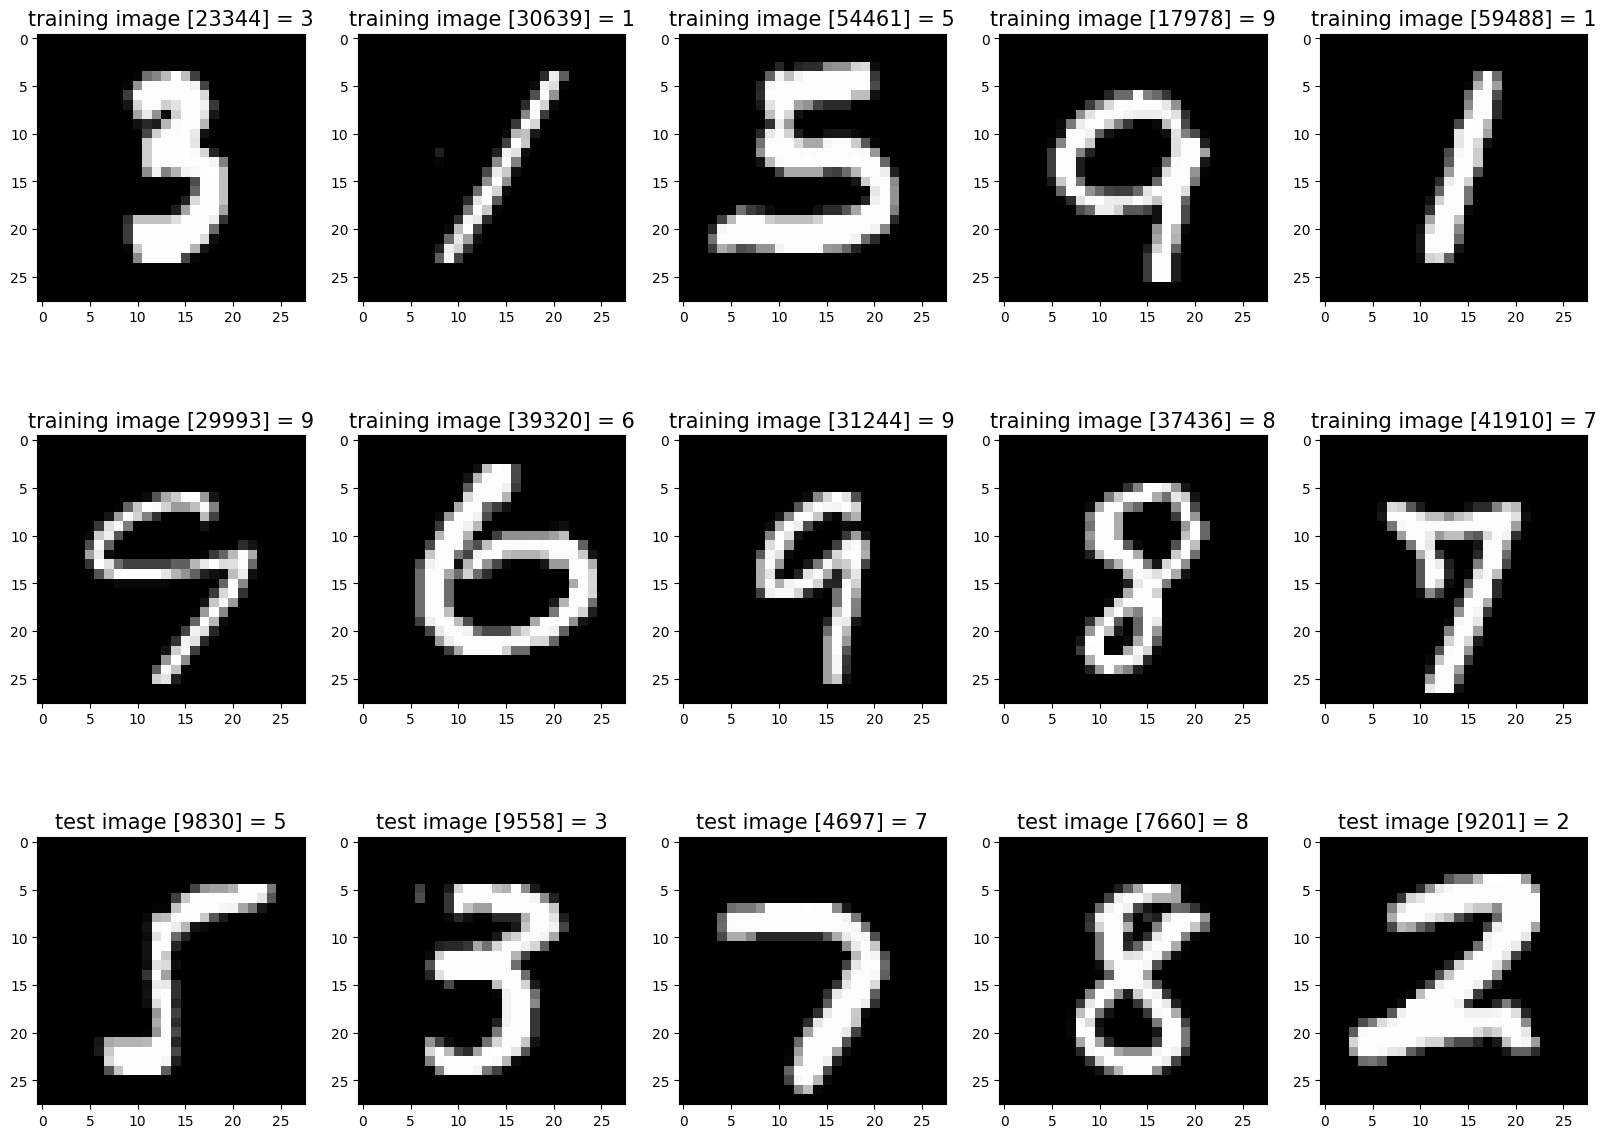

In [29]:
#now to see the images 

#setting the paths
#
# Verify Reading Dataset via MnistDataloader class
#
%matplotlib inline
import random
import matplotlib.pyplot as plt
from os.path  import join

#
# Set file paths based on added MNIST Datasets
#
input_path = '/kaggle/input/datasets/hojjatk/mnist-dataset'
train_imagefilepath = join(input_path, 'train-images-idx3-ubyte/train-images-idx3-ubyte')
train_lablefilepath = join(input_path, 'train-labels-idx1-ubyte/train-labels-idx1-ubyte')
test_image_filepath = join(input_path, 't10k-images-idx3-ubyte/t10k-images-idx3-ubyte')
test_lablefilepath = join(input_path, 't10k-labels-idx1-ubyte/t10k-labels-idx1-ubyte')

def seeimages(images,title):

    col = 5
    rows = int(len(images)/col) + 1

    plt.figure(figsize=(20,20))

    index = 1

    for image,title_text in zip(images,title):

        plt.subplot(rows,col,index)
        plt.imshow(image,cmap=plt.cm.gray)

        if title_text != "":
            plt.title(title_text,fontsize=15)

        index += 1

minist_dataloader=MinistData(train_imagefilepath,train_lablefilepath,test_image_filepath,test_lablefilepath)
train_img,train_label,test_img,test_label=minist_dataloader.loaddata()   


img_2_show=[]
tit_2_show=[]

# 10 random training images
for i in range(10):
    r=random.randint(0,59999)
    img_2_show.append(train_img[r])
    tit_2_show.append("training image ["+str(r)+"] = "+str(train_label[r]))

# 5 random test images
for i in range(5):
    r=random.randint(0,9999)
    img_2_show.append(test_img[r])        
    tit_2_show.append('test image [' + str(r) + '] = ' + str(test_label[r]))    

# Show images
seeimages(img_2_show, tit_2_show) 

    

In [30]:
X_train=train_img
X_test=test_img
y_train=train_label
y_test=test_label


dataset= returns one sample when asked
dataloader=takes our data and give to model in batches 

In [31]:
import numpy as np

class NumpyDataset:
    def __init__(self, X, y):
        if X.shape[0] != y.shape[0]:
            raise ValueError("X and y must have the same number of samples.")
        self.X = X
        self.y = y

    def __len__(self):
        return self.X.shape[0]

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


class DataLoader:
    def __init__(self, dataset, batch_size=32, shuffle=True, drop_last=False, seed=42):
        self.dataset = dataset
        self.batch_size = batch_size
        self.shuffle = shuffle
        self.drop_last = drop_last
        self.rng = np.random.default_rng(seed)

    def __iter__(self):
        n = len(self.dataset)
        indices = np.arange(n)

        if self.shuffle:
            self.rng.shuffle(indices)

        # yield batches
        for start in range(0, n, self.batch_size):
            end = start + self.batch_size
            batch_idx = indices[start:end]

            if self.drop_last and len(batch_idx) < self.batch_size:
                continue

            X_batch = self.dataset.X[batch_idx]
            y_batch = self.dataset.y[batch_idx]
            yield X_batch, y_batch

Input → Dense → ReLU → Dense → Sigmoid → Binary Cross Entropy

relu=activation function= introduce non linearity ,to learn complex pattern
sigmoid=used for binary classifcation output,also an activation function 

forward means computing the output of the activation function, and backward means computing the gradient (derivative) used in backpropagation to update weights.

backpropagation=updating weight and biases 

In [32]:
import numpy as np

# ---------- Activations ----------
class ReLU:
    def forward(self, X):
        self.X = X
        return np.maximum(0, X)

    def backward(self, dY):
        # Gradient passes only where X > 0
        return dY * (self.X > 0)

class Sigmoid:
    def forward(self, X):
        X = np.clip(X, -500, 500)
        self.Y = 1 / (1 + np.exp(-X))
        return self.Y

    def backward(self, dY):
        # derivative: s*(1-s)
        return dY * (self.Y * (1 - self.Y))


In [33]:

# ---------- Layer ----------
class DenseLayer:
    def __init__(self, in_features, out_features, seed=42):
        rng = np.random.default_rng(seed)
        # Small random init
        self.W = rng.normal(0, 0.01, size=(in_features, out_features))
        self.b = np.zeros((1, out_features))

    def forward(self, X):
        self.X = X  # cache input for backprop
        return X @ self.W + self.b

    def backward(self, dZ):
        # dZ is gradient wrt output of this layer
        # gradients for parameters:
        self.dW = self.X.T @ dZ
        self.db = np.sum(dZ, axis=0, keepdims=True)

        # gradient wrt input to this layer:
        dX = dZ @ self.W.T
        return dX

    def step(self, lr):
        self.W -= lr * self.dW
        self.b -= lr * self.db


In [34]:
# ---------- Loss ----------
class BinaryCrossEntropyLoss:
    def forward(self, y_pred, y_true, eps=1e-12):
        # clamp to avoid log(0)
        y_pred = np.clip(y_pred, eps, 1 - eps)
        self.y_pred = y_pred
        self.y_true = y_true

        # BCE: -[ y*log(p) + (1-y)*log(1-p) ]
        loss = -(y_true * np.log(y_pred) + (1 - y_true) * np.log(1 - y_pred))
        return np.mean(loss)

    def backward(self):
        # derivative of BCE wrt y_pred:
        # dL/dp = -(y/p) + (1-y)/(1-p)
        y = self.y_true
        p = self.y_pred
        n = y.shape[0]
        return (-(y / p) + (1 - y) / (1 - p)) / n

In [35]:
# ---------- Network ----------
class NeuralNetwork:
    def __init__(self, input_dim, hidden_dim=16):
        self.fc1 = DenseLayer(input_dim, hidden_dim)
        self.relu = ReLU()
        self.fc2 = DenseLayer(hidden_dim, 1)
        self.sigmoid = Sigmoid()
        self.loss_fn = BinaryCrossEntropyLoss()

    def forward(self, X):
        z1 = self.fc1.forward(X)
        a1 = self.relu.forward(z1)
        z2 = self.fc2.forward(a1)
        y_pred = self.sigmoid.forward(z2)
        return y_pred

    def compute_loss(self, y_pred, y_true):
        return self.loss_fn.forward(y_pred, y_true)

    def backward(self):
        dL_dpred = self.loss_fn.backward()
        dZ2 = self.sigmoid.backward(dL_dpred)
        dA1 = self.fc2.backward(dZ2)
        dZ1 = self.relu.backward(dA1)
        _ = self.fc1.backward(dZ1)

    def step(self, lr):
        self.fc1.step(lr)
        self.fc2.step(lr)

    def fit(self, X_train, y_train, epochs=200, lr=0.1, verbose_every=20):
        for epoch in range(1, epochs + 1):
            y_pred = self.forward(X_train)
            loss = self.compute_loss(y_pred, y_train)

            self.backward()
            self.step(lr)

            if epoch % verbose_every == 0 or epoch == 1:
                acc = self.accuracy(X_train, y_train)
                print(f"Epoch {epoch:4d} | Loss: {loss:.4f} | Train Acc: {acc:.4f}")

    def predict_proba(self, X):
        return self.forward(X)

    def predict(self, X, threshold=0.5):
        proba = self.predict_proba(X)
        return (proba >= threshold).astype(np.int64)

    def accuracy(self, X, y_true):
        y_hat = self.predict(X)
        return np.mean(y_hat == y_true)


In [36]:
import numpy as np

# Convert to numpy
X_train = np.array(train_img)
X_test = np.array(test_img)

y_train = np.array(train_label).reshape(-1,1)
y_test = np.array(test_label).reshape(-1,1)

# Flatten images (28x28 → 784)
X_train = X_train.reshape(X_train.shape[0], -1)
X_test = X_test.reshape(X_test.shape[0], -1)

print(X_train.shape)   # (60000, 784)
print(X_test.shape)    # (10000, 784)

(60000, 784)
(10000, 784)


In [37]:
import numpy as np

class StandardScalerFromScratch:

    def __init__(self):
        self.mean = None
        self.std = None

    def fit(self, X):
        # compute mean and std for each feature
        self.mean = np.mean(X, axis=0)
        self.std = np.std(X, axis=0)

    def transform(self, X):
        # apply normalization
        return (X - self.mean) / (self.std + 1e-8)

    def fit_transform(self, X):
        # fit then transform
        self.fit(X)
        return self.transform(X)

In [38]:


# ---------- Example usage ----------
if __name__ == "__main__":

    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)

    nn = NeuralNetwork(input_dim=X_train.shape[1], hidden_dim=16)
    nn.fit(X_train, y_train, epochs=300, lr=0.1, verbose_every=30)

    test_acc = nn.accuracy(X_test, y_test)
    print("Test accuracy:", test_acc)

    # Make prediction on first 5 test samples
    probs = nn.predict_proba(X_test[:5])
    preds = nn.predict(X_test[:5])
    print("Probabilities:\n", probs)
    print("Predictions:\n", preds.T)
    print("True labels:\n", y_test[:5].T)

Epoch    1 | Loss: 140.6752 | Train Acc: 0.0987
Epoch   30 | Loss: 36.9266 | Train Acc: 0.0987
Epoch   60 | Loss: 27.7914 | Train Acc: 0.0987
Epoch   90 | Loss: 24.7091 | Train Acc: 0.0987
Epoch  120 | Loss: 22.0345 | Train Acc: 0.0987
Epoch  150 | Loss: 21.3641 | Train Acc: 0.0987
Epoch  180 | Loss: 21.1454 | Train Acc: 0.0987
Epoch  210 | Loss: 21.0882 | Train Acc: 0.0987
Epoch  240 | Loss: 21.0312 | Train Acc: 0.0987
Epoch  270 | Loss: 21.0162 | Train Acc: 0.0988
Epoch  300 | Loss: 21.0342 | Train Acc: 0.0992
Test accuracy: 0.0983
Probabilities:
 [[0.02565679]
 [0.00709036]
 [0.22341545]
 [0.01213225]
 [0.02569087]]
Predictions:
 [[0 0 0 0 0]]
True labels:
 [[7 2 1 0 4]]
